# Assignment 4.1

Name:  
Date:

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

## Problem # 4.1.

For a point estimate of the mean of a population that is assumed to have a normal distribution,
a data scientist decides to use the average of the sample lower and upper quartiles for the $n = 100$
observations, since unlike the sample mean $\bar{Y}$, the quartiles are not affected by outliers. Evaluate
the precision of this estimator compared to $\bar{Y}$ by randomly generating 100,000 samples of size
100 each from a $N(0, 1)$ distribution and comparing the standard deviation of the 100,000
estimates with the theoretical standard error of $\bar{Y}$.

`Your answer goes here`

In [1]:
import numpy as np

# Sample Size
n = 100
SAMPLES = int(1e5)

# Random seed for reproducibility
rng = np.random.default_rng(73)

# Normal dist params
sig = 1
mew = 0

# Critical values
Z_68 = 1
Z_95 = 1.96
Z_99 = 2.576

# Generating 100_000 samples of size 100 w/ avg of lower/upper quartiles
y = []
for samp in range(SAMPLES):
    # Generating random variates
    x = rng.normal(size=n)
    # Average of 3rd and 1st quartile
    y_bar_i = (np.quantile(x, 0.75) + np.quantile(x, 0.25)) / 2
    y.append(y_bar_i)

# Estimate standard deviation (not sample, population estimate)
est_std = np.std(y, ddof=1)
y_bar = np.mean(y)

# Theoretical standard error
se = sig / np.sqrt(n)

print(f"Estimated standard deviation: {est_std:.3f}")
print(f"Theoretical standard error: {se:.3f}")
print(f"Mean of estimator (sampling mean): {y_bar:.3f}\n")

# Confidence Intervals to evaluate precision
# Confidence Levels: 68, 95, 99 % w/ critical values: 1, 1.96, 2.576
ci_68_q = (mew - Z_68 * est_std, mew + Z_68 * est_std)
ci_95_q = (mew - Z_95 * est_std, mew + Z_95 * est_std)
ci_99_q = (mew - Z_99 * est_std, mew + Z_99 * est_std)

# Confidence Intervals for the sample mean
ci_68 = (mew - Z_68 * se, mew + Z_68 * se)
ci_95 = (mew - Z_95 * se, mew + Z_95 * se)
ci_99 = (mew - Z_99 * se, mew + Z_99 * se)

print("Typical Error bands for estimator (quartile):")
print(f"68% CI: ({ci_68_q[0]:.3f}, {ci_68_q[1]:.3f})")
print(f"95% CI: ({ci_95_q[0]:.3f}, {ci_95_q[1]:.3f})")
print("Confidence INtervals for sample mean:")
print(f"68% CI: ({ci_68[0]:.3f}, {ci_68[1]:.3f})")
print(f"95% CI: ({ci_95[0]:.3f}, {ci_95[1]:.3f})")
print(f"99% CI: ({ci_99[0]:.3f}, {ci_99[1]:.3f})")

# Interpretation
print("\nINTERPRETATION:")
print(60*"+")
print(f"""
Quartile-based estimator is approximately unbiased, since the sampling mean ({y_bar:.3f}) which is almost equal to the true population mean ({mew}).
sampling variability is higher than the sample mean, where the estimated SD (quartile) is {est_std:.3f} and the theoretical standard deviation is {se:.3f}.
This shows an increase in variabiliity of about {((est_std)/se - 1)*100:.1f}% relative to sample mean.
The confidence intervals based on quartiles are wider for each, meaning lowercprecision.

When the data contains no outliers (as with our N(0,1) simulation), the midhinge's robustness provides no benefit, yet we still pay the cost of increased variance."
      """)
print(60*"+")


Estimated standard deviation: 0.111
Theoretical standard error: 0.100
Mean of estimator (sampling mean): 0.000

Typical Error bands for estimator (quartile):
68% CI: (-0.111, 0.111)
95% CI: (-0.218, 0.218)
Confidence INtervals for sample mean:
68% CI: (-0.100, 0.100)
95% CI: (-0.196, 0.196)
99% CI: (-0.258, 0.258)

INTERPRETATION:
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

Quartile-based estimator is approximately unbiased, since the sampling mean (0.000) which is almost equal to the true population mean (0).
sampling variability is higher than the sample mean, where the estimated SD (quartile) is 0.111 and the theoretical standard deviation is 0.100.
This shows an increase in variabiliity of about 11.1% relative to sample mean.
The confidence intervals based on quartiles are wider for each, meaning lowercprecision.

When the data contains no outliers (as with our N(0,1) simulation), the midhinge's robustness provides no benefit, yet we still pay the cost of increase

## Problem # 4.2.

For a sequence of observations of a binary random variable, you observe the geometric random
variable (Section 2.2.2) outcome of the first success on observation number $y = 3$. Find and plot
the likelihood function.

`Your answer goes here`

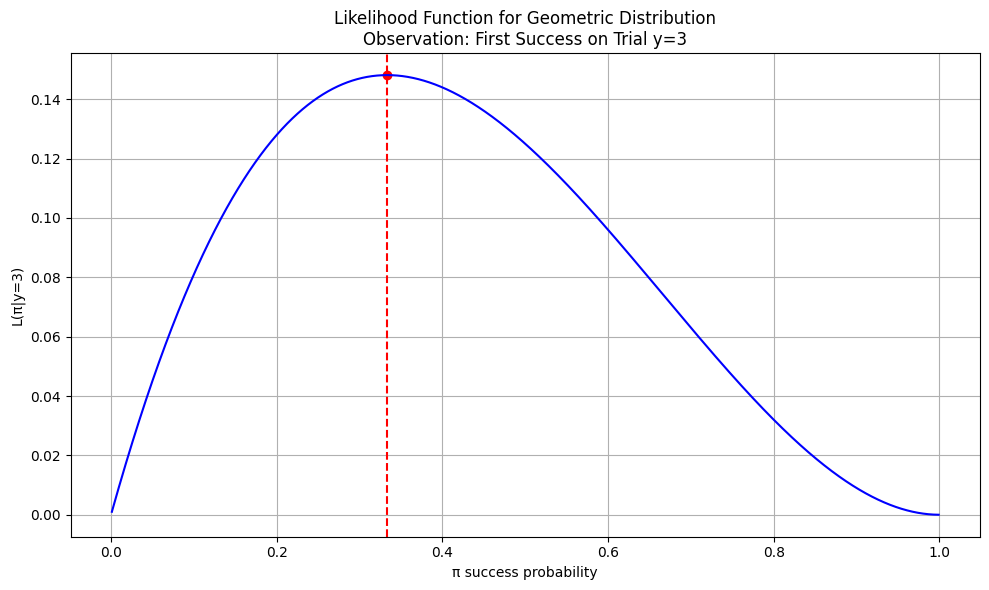

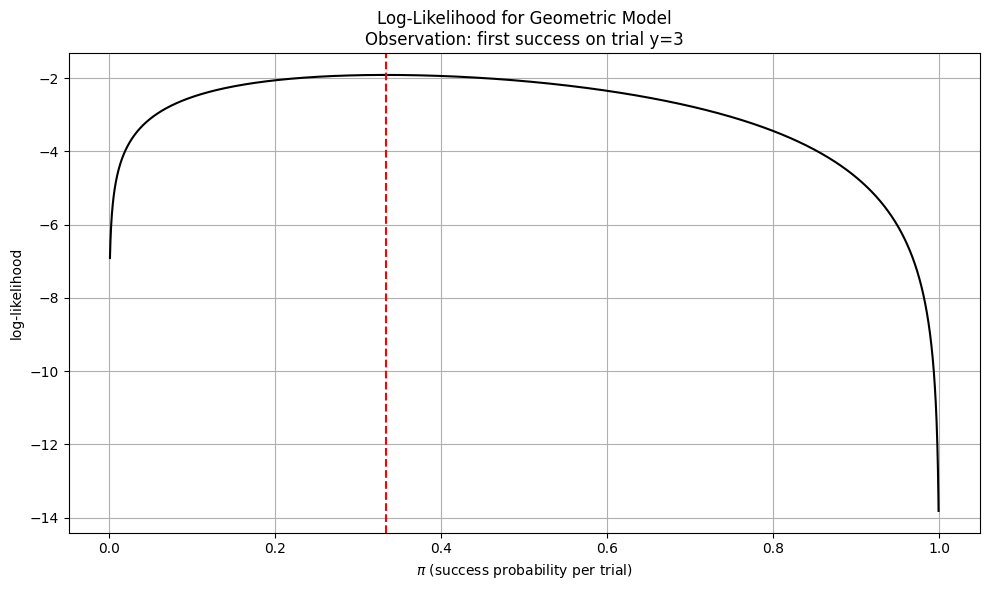


The likelihood function is L(π) = (1 - π)^(y-1), where π is the trial of each success probbability, and L(π) measures how compatible each π s with the observed data y = 3.  

IT's maximized at π̂ = 1 / y = 0.333, which is the maximium likelihood estimate of the success probability, which shows that two failures followed by a success.
      


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# First success @ y = 3
y = 3

# Array of possible pi values, arbitrarily chosen number of samples
pi_pts = np.linspace(0.001, 0.999, int(1e4))

# Likelihood for geometric dist
L = ((1 - pi_pts)**(y-1)) * pi_pts

# MLE
pi_hat = 1 / y

# Likelihood @ MLE for marking in plot
L_hat = ((1 - pi_hat)**(y-1)) * pi_hat

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(pi_pts, L, "b-", label="Likelihood: L(\u03C0) = P(Y=3 | \u03C0)"
)
plt.axvline(pi_hat, color="red", linestyle="--", label=f"MLE: pi_hat = 1 / {y} = {pi_hat:.3f}")
plt.scatter([pi_hat], [L_hat], color="red")
plt.xlabel("\u03C0 success probability")
plt.ylabel("L(\u03C0|y=3)")
plt.title("Likelihood Function for Geometric Distribution\nObservation: First Success on Trial y=3")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting the log-likelihood
logL = np.log(L)

plt.figure(figsize=(10, 6))
plt.plot(pi_pts, logL, "k-", label=r"$\ell(\pi)=\log L(\pi)$")
plt.axvline(pi_hat, color="red", linestyle="--", label=f"MLE: {pi_hat:.3f}")
plt.xlabel(r"$\pi$ (success probability per trial)")
plt.ylabel(r"log-likelihood")
plt.title(f"Log-Likelihood for Geometric Model\nObservation: first success on trial y={y}")
plt.grid(True)
plt.tight_layout()
plt.show()

# Interpretation
print(f"""
The likelihood function is L(\u03C0) = (1 - \u03C0)^(y-1), where \u03C0 is the trial of each success probbability, and L(\u03C0) measures how compatible each \u03C0 s with the observed data y = {y}.  

IT's maximized at \u03C0\u0302 = 1 / y = {pi_hat:.3f}, which is the maximium likelihood estimate of the success probability, which shows that two failures followed by a success.
      """)


## Problem # 4.11.

The observations on number of hours of daily TV watching for the 10 subjects in the 2018 GSS
who identified themselves as Islamic were 0, 0, 1, 1, 1, 2, 2, 3, 3, 4.

(a)  Construct and interpret a 95% confidence interval for the population mean.
(b)  Suppose the observation of 4 was incorrectly recorded as 24. What would you obtain for
the 95% confidence interval? What does this suggest about potential effects of outliers on
confidence intervals for means?

`(a) Your answer goes here`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from textwrap import dedent

def ci_construction(y, cl=0.95):
    """
    Constructs a Confidence interval for the given sample with quantitative (discrete) values in order to infer the unknown population mean.
    ------------------------------------------------
    INPUT:
        y: (list, np.array, pd.DataFrame, pd.Series) Sample of values (not a large sample).
        cl: (float) Confindence Level (default 0.95)

    OUTPUT:
        tuple of values: (sample mean, sample standard deviation, standard error, degrees of freedom, t-critical value, margine of error, confidence interval)
    """
    if isinstance(y, pd.DataFrame):
        y = y.loc[:, 0]

    if isinstance(y, pd.Series):
        y = y.to_numpy()

    # Sample size
    n = len(y)

    # Confidence Level check
    if cl == 0.95:
        # t quantile having probability a in the right-tail
        alpha = 0.025

    else:
        alpha = (1 - cl) / 2

    # Sample Statistics
    mew_hat = sum(y) / n # sample meann
    std = np.std(y, ddof=1) # Sample standard deviatition
    se = std / np.sqrt(n) # Standard error

    # t-critical value
    df = n - 1 # Degrees of freedom
    t_crit = t.ppf(1 - alpha, df=df)

    # Margin of error
    me = t_crit * se

    # Confidence Interval for confidence level 95%
    ci = (mew_hat - me, mew_hat + me)

    return (mew_hat, std, se, df, t_crit, me, ci)


# Part a) - unpack results once
# a)
y = [0, 0, 1, 1, 1, 2, 2, 3, 3, 4]
n = len(y) # Sample size
mew_hat, std, se, df, t_crit, me, ci = ci_construction(y)

print(f"Fore the sample: {y}")
print(f"Sample Mean: {mew_hat:.3f}")
print(f"Sampe Standard Deviation: {std:.3f}")
print(f"Standard Error: {se:.3f}")
print(f"Degrees of Freedom: df = {n} - 1 = {df}")
print(f"t-critical value for a 95% CI: {t_crit:.3f}")
print(f"Margin of Error: {me:.3f}")
print(f"Confidence interval: ({ci[0]:.3f}, {ci[1]:.3f})")

# Interpretation
print(dedent(f"""a)
    Assumptions: Normal distribution of the population.
    We can be 95% confident that the true population for the daily hours spent watching tv is lies between {ci[0]:.3f} and {ci[1]:.3f} hours per day.
    Confidence interval made by using a t-distribution since the population std dev is uknown, with a small sample size of {n}.  the interval shows the sample mean {mew_hat:.3f} and sampling variabislity of the mean as the standard error {se:.3f}.

    Interpreted probabilistically, if we were to repeatedly take many rand samples of size 10 from this population mean and construct a 95% confidence interval in the same way each time, approximately 95% of those intervals would contain the true population mean.
    """))



Fore the sample: [0, 0, 1, 1, 1, 2, 2, 3, 3, 4]
Sample Mean: 1.700
Sampe Standard Deviation: 1.337
Standard Error: 0.423
Degrees of Freedom: df = 10 - 1 = 9
t-critical value for a 95% CI: 2.262
Margin of Error: 0.957
Confidence interval: (0.743, 2.657)
a)
    Assumptions: Normal distribution of the population.
    We can be 95% confident that the true population for the daily hours spent watching tv is lies between 0.743 and 2.657 hours per day.
    Confidence interval made by using a t-distribution since the population std dev is uknown, with a small sample size of 10.  the interval shows the sample mean 1.700 and sampling variabislity of the mean as the standard error 0.423.

    Interpreted probabilistically, if we were to repeatedly take many rand samples of size 10 from this population mean and construct a 95% confidence interval in the same way each time, approximately 95% of those intervals would contain the true population mean.



`(b) Your answer goes here`

In [3]:
# b)
y_24 = [0, 0, 1, 1, 1, 2, 2, 3, 3, 24]

# Part b) - unpack results once
mew_hat_24, std_24, se_24, df_24, t_crit_24, me_24, ci_24 = ci_construction(y_24)

print(f"Fore the sample: {y_24}")
print(f"Sample Mean: {mew_hat_24:.3f}")
print(f"Sampe Standard Deviation: {std_24:.3f}")
print(f"Standard Error: {se_24:.3f}")
print(f"Degrees of Freedom: df = {n} - 1 = {df_24}")
print(f"t-critical value for a 95% CI: {t_crit_24:.3f}")
print(f"Margin of Error: {me_24:.3f}")
print(f"Confidence interval: ({ci_24[0]:.3f}, {ci_24[1]:.3f})")

# Interprtation
print(dedent(f"""
    b)
    Using data where the value 24 was incorrectly recorded, we get a 95% confidence
    interval for the population mean for the daily number of hours of tv
    watching as ({ci_24[0]:.3f}, {ci_24[1]:.3f}),
    which is a lot wider than in part a) since the outlier throws off the
    sample mean {mew_hat_24:.3f} and inflates the sample standard
    error {std_24:.3f}, which increases the standard error
    {se_24:.3f} along with the margin of error
    {me_24:.3f}
    """))


Fore the sample: [0, 0, 1, 1, 1, 2, 2, 3, 3, 24]
Sample Mean: 3.700
Sampe Standard Deviation: 7.212
Standard Error: 2.281
Degrees of Freedom: df = 10 - 1 = 9
t-critical value for a 95% CI: 2.262
Margin of Error: 5.159
Confidence interval: (-1.459, 8.859)

b)
Using data where the value 24 was incorrectly recorded, we get a 95% confidence
interval for the population mean for the daily number of hours of tv
watching as (-1.459, 8.859),
which is a lot wider than in part a) since the outlier throws off the
sample mean 3.700 and inflates the sample standard
error 7.212, which increases the standard error
2.281 along with the margin of error
5.159



## Problem # 4.14.

Using the Students data file, for the corresponding population, construct a 95% confidence interval **(a)** for the mean weekly number of hours spent watching TV; **(b)** to compare females and
males on the mean weekly number of hours spent watching TV. In each case, state assumptions,
including the practical importance of each, and interpret results.

`Your answer goes here`

In [10]:
import numpy as np
from scipy.stats import t
import pandas as pd
from textwrap import dedent
from assign4_11 import ci_construction

df = pd.read_csv("./students.dat", sep="\s+")

# a) variables in quetion
tv_hrs = df["tv"]

# Calculate confidence interval w/ all relevant statistical values
results = ci_construction(tv_hrs)
mew_hat, s, se, dfree, tcrit, me, ci = results

print("95% Confidence Interval for Mean Weekly TV Hours")
print("=" * 20)
print(f"Sample mean (ȳ): {mew_hat:.2f} hours/week")
print(f"Sample standard deviation (s): {s:.2f}")
print(f"Standard error (SE = s/√n): {se:.2f}")
print(f"Degrees of freedom: {dfree}")
print(f"t-critical value (95%): {tcrit:.3f}")
print(f"Margin of error: {me:.2f}\n")

print(f"95% Confidence Interval:")
print(f"({ci[0]:.2f}, {ci[1]:.2f}) hours/week\n")

print("INTERPRETATION:")
print("-" * 20)
print(dedent(f"""
We can be 95% confident that the true population mean (weekly number of hours
wathcing tv) lies between {ci[0]:.2f} and {ci[1]:.2f}
hours.\nMeaning, if were to iteratively take random samples of
students and develop the confidence intervals, approximately 95%
of those would contain the true population mean.
             """))

print(dedent(f"""
ASSUMPTIONS AND THERE IMPORTANCE:
The t-distribution assumed independent observations from a random sample from the population, where if the data weren't randomly collected, the
sampling wouldn't reflect the population and the interval would
describe the uncertainty about the sample and not the population.
It also assumes that the population is approximately normal.

We would probably expect the distribution of the hours of tv being watched to
be right-skewed, since there's no negative time, but 
thanks to the Central Limit Theorem, even if the population distribution is
skewed, the sampling distribution of the mean becomes
approximately normal for moderate n.
             """))

# For part b) Comparing females and males
tv_gender = df[["tv", "gender"]]
male = tv_gender[tv_gender["gender"] == 0]
female = tv_gender[tv_gender["gender"] == 1]
male_results = ci_construction(male["tv"])
female_results = ci_construction(female["tv"])

# Sample sizes
n_male = len(male)
n_female = len(female)

# Sample Statistics
m_mew, m_s, m_se, m_df, m_tcrit, m_me, m_ci = male_results
f_mew, f_s, f_se, f_df, f_tcrit, f_me, f_ci = female_results

# Pooled sample mean
diff_hat = m_mew - f_mew

# Pooled estimate (sample standard deviation) and assumes equal variance !!
pool_est = np.sqrt(((n_male - 1) * (m_s)**2 + (n_female - 1) * (f_s)**2) /
                   ((n_male - 1) + (n_female - 1)))

# Standard error
pool_se = pool_est * np.sqrt((1/n_male) + (1/n_female))

# Degrees of Freedom
dof = n_male + n_female - 2

# t quantile having probability a in the right-tail
alpha = 0.025
# t-critical value, where 1-alpha = cumulative probability
t_crit = t.ppf(q=1-alpha, df=dof)

# Marginal Error
me = t_crit * pool_se

# Confidence Intervals
ci = (diff_hat - me, diff_hat + me)

# Output
print("\n================ SAMPLE STATISTICS =================\n")

print("Male group:")
print(f"  Sample mean (x̄_m):        {m_mew:.3f}")
print(f"  Sample SD (s_m):           {m_s:.3f}")
print(f"  Standard Error (SE_m):     {m_se:.3f}")
print(f"  Degrees of Freedom:        {m_df}")
print(f"  t-critical value:          {m_tcrit:.3f}")
print(f"  Margin of Error:           {m_me:.3f}")
print(f"  95% CI for μ_m:            ({m_ci[0]:.3f}, {m_ci[1]:.3f})\n")

print("Female group:")
print(f"  Sample mean (x̄_f):        {f_mew:.3f}")
print(f"  Sample SD (s_f):           {f_s:.3f}")
print(f"  Standard Error (SE_f):     {f_se:.3f}")
print(f"  Degrees of Freedom:        {f_df}")
print(f"  t-critical value:          {f_tcrit:.3f}")
print(f"  Margin of Error:           {f_me:.3f}")
print(f"  95% CI for μ_f:            ({f_ci[0]:.3f}, {f_ci[1]:.3f})\n")


print("\nINTERPRETATION:")
print(dedent(f"""
Estimating the difference in mean weekly TV watching hours between men and women,
the 95% confidence interval includes 0, indicating no statistically detectable
difference between the population means at the 95% confidence level.

The 95% confidence interval is ({ci[0]:.3f}, {ci[1]:.3f}). Since this interval
{"includes 0, we do not have evidence of a difference in the population means"
 if ci[0] <= 0 <= ci[1]
 else "does not include 0, we have evidence of a difference in the population means"}
at the 95% confidence level.

Practical Importance: 
The data is consistent with males watching from {ci[0]:.2f} to {ci[1]:.2f} hours/week more TV than females (negative means fewer).
If differences of ~2 hours/week are meaningful in context, note whether that range is
included/excluded by the interval.
"""))


print(dedent(f"""
ASSUMPTIONS FOR THE TWO-SAMPLE (POOLED) t-INTERVAL AND THEIR IMPORTANCE:
1) Random sampling / representativeness within each gender group: Needed to generalize
   to the population of students in each group.
2) Independence: Within and between groups; needed for the pooled SE formula.
3) Equal population variances (σ_m^2 = σ_f^2): This is required for the pooled t interval.
   If badly violated, the pooled interval can be inaccurate (too wide or too narrow).
4) Population shape / outliers: Each group's TV-hours distribution may be right-skewed,
   but with moderate n the CLT supports approximate normality of the group means.
             """))


95% Confidence Interval for Mean Weekly TV Hours
Sample mean (ȳ): 7.27 hours/week
Sample standard deviation (s): 6.72
Standard error (SE = s/√n): 0.87
Degrees of freedom: 59
t-critical value (95%): 2.001
Margin of error: 1.74

95% Confidence Interval:
(5.53, 9.00) hours/week

INTERPRETATION:
--------------------

We can be 95% confident that the true population mean (weekly number of hours
wathcing tv) lies between 5.53 and 9.00
hours.
Meaning, if were to iteratively take random samples of
students and develop the confidence intervals, approximately 95%
of those would contain the true population mean.


ASSUMPTIONS AND THERE IMPORTANCE:
The t-distribution assumed independent observations from a random sample from the population, where if the data weren't randomly collected, the
sampling wouldn't reflect the population and the interval would
describe the uncertainty about the sample and not the population.
It also assumes that the population is approximately normal.

We would probably e

## Problem # 4.31.

The `Houses` data file at the book’s website lists, for 100 home sales in Gainesville, Florida,
several variables, including the selling price in thousands of dollars and whether the house
is new (1 = yes, 0 = no). Prepare a short report in which, stating all assumptions including
the relative importance of each, you conduct descriptive and inferential statistical analyses to
compare the selling prices for new and older homes.

`Your answer goes here`

## Problem 5.6.

Before a Presidential election, polls are taken in two swing states. The Republican candidate
was preferred by 59 of the 100 people sampled in state A and by 525 of 1000 sampled in state
B. Treat these as independent binomial samples, where the parameter $\pi$ is the population
proportion voting Republican in the state.


(a) If we can treat these polls as if the samples were random, use significance tests of $H_0$:
$\pi  = 0.50$ against $H_a:  \pi > 0.50$ to determine which state has greater evidence supporting a
Republican victory. Explain your reasoning.


`Your answer goes here`

(b) Conduct a Bayesian analysis to answer the question in (a) by finding in each case the
posterior $P(\pi < 0.50)$, corresponding to the *P-* value in (a). Use beta(50, 50) priors, which
have standard deviation 0.05 and reflect the pollster’s strong prior belief that $\pi$ almost
surely is between 0.35 and 0.65. Explain any differences between conclusions.

`Your answer goes here`

## Problem 5.8.

For the `Students` data file at the text website, analyze political ideology.

(a) Test whether the population mean $\mu$ differs from 4.0, the moderate response. Report the
*P*-value, and interpret. Make a conclusion using $\alpha$ - level = 0.05.

`Your answer goes here`

(b) Construct the 95% confidence interval for $\mu$. Explain how results relate to those of the
test in (a).


`Your answer goes here`

## Problem 5.10.

A study of sheep mentioned in Exercise 1.27 analyzed whether the sheep survived for a year
from the original observation time (1 = yes, 0 = no) as a function of their weight (*kg*) at the
original observation. Stating any assumptions including the conceptual population of interest,
use a *t* test with the data in the Sheep data file at the text website to compare mean weights
of the sheep that survived and did not survive. Interpret the *P*-value.

`Your answer goes here`

## Problem 5.23. Sentiment Toward AI and Gender

You will use a mock survey dataset that measures public sentiment toward artificial intelligence. Your task is to generate the dataset, construct a contingency table, and test whether sentiment depends on gender

### Dataset creation

Run the starter code below to generate the dataset as a pandas DataFrame named `df_ai`.

In [2]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(2024)

# Sample size
n = 300

# Categories
sentiments = ["Positive", "Neutral", "Negative"]
genders = ["Male", "Female", "Other"]
usage_levels = ["Daily", "Weekly", "Rarely", "Never"]

# Generate the DataFrame
df_ai = pd.DataFrame(
    {
        "sentiment": np.random.choice(sentiments, size=n, p=[0.44, 0.33, 0.23]),
        "gender": np.random.choice(genders, size=n, p=[0.49, 0.48, 0.03]),
        "age": np.random.randint(18, 75, size=n),
        "ai_usage_frequency": np.random.choice(usage_levels, size=n),
        "trust_in_ai": np.random.randint(1, 6, size=n),
    }
)

df_ai.head()

,sentiment,gender,age,ai_usage_frequency,trust_in_ai
0,Neutral,Male,55,Weekly,2
1,Neutral,Male,23,Rarely,3
2,Positive,Male,27,Daily,5
3,Positive,Female,29,Daily,1
4,Positive,Female,58,Rarely,5


| Variable           | Description                         |
|--------------------|-------------------------------------|
| `sentiment`          | Sentiment toward AI                 |
| `gender`             | Gender identity                     |
| `age`                | Respondent age                      |
| `ai_usage_frequency` | AI tool usage frequency             |
| `trust_in_ai`        | Trust in AI from 1 to 5             |

Using the dataset you just created:

(a) Form a contingency table that cross classifies sentiment by gender.

(b) For the hypothesis $H_0:$ sentiment toward AI is independent of gender, conduct a chi squared test of independence.

(c) Interpret the results in the context of attitudes toward AI.

(a) `Your answer goes here`

(b) `Your answer goes here`


(c) `Your answer goes here`
